# Portfolio Assessment 1: Exploratory Data Analysis (EDA) & Data Preparation

Course: COS40007 - AI Engineering  
Student Name: Le Mai Chi  
Student ID: 105555880 <br>
Data Name: NASA Battery Dataset <br> 
Data Source: https://www.kaggle.com/datasets/patrickfleith/nasa-battery-dataset


## Imports, Format

Load the necessary libraries and modify the output format

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Environment (for reproducibility)
import sys, platform, matplotlib
print("Python    :", sys.version.split()[0], "|", platform.platform())
print("numpy     :", np.__version__)
print("pandas    :", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn   :", sns.__version__)

Python    : 3.14.5 | macOS-26.6.2-arm64-arm-64bit-Mach-O
numpy     : 2.5.3
pandas    : 3.0.6
matplotlib: 3.11.2
seaborn   : 0.13.2


In [3]:
# format for convenient loading
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [4]:
# load metadata.csv
candidates = list(Path("../dataset/").rglob("metadata.csv"))

valid = [p for p in candidates if (p.parent / "data").exists()]
if not valid:
    raise FileNotFoundError("Could not find metadata.csv.")

META_PATH = valid[0]
DATA_DIR = META_PATH.parent / "data"

OUTPUT_DIR = Path("../output")

FEATURE_PATH = OUTPUT_DIR / "battery_discharge_features.csv"
CLEAN_DATA_PATH = OUTPUT_DIR / "nasa_battery_eda_clean.csv"

# print("Metadata:", META_PATH)
# print("Data folder:", DATA_DIR)
# print("Output folder:", OUTPUT_DIR)

# Set True to rebuild the feature table from the raw CSV files (ignores the cache)
FORCE_REBUILD = True


**Data source note:** The Kaggle author (Fleith, n.d.) converted the original NASA `.mat` files into CSV format. The CSV files are stored in `dataset/`. The underlying measurements come from the NASA PCoE Battery Data Set (Saha and Goebel, 2007).<br>
<br>
CSV version used: https://www.kaggle.com/datasets/patrickfleith/nasa-battery-dataset <br>
Original repository: https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/


In [5]:
FIG_DIR = Path("../output/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Task 1: Dataset Loading & Initial Exploration

The metadata contains charge, discharge and impedance experiments. Since `Capacity` is the target of interest and belongs to discharge experiments, only discharge cycles are used to construct the analytical dataset.


In [6]:
meta = pd.read_csv(META_PATH, dtype={"filename": str})

# Convert expected numerical columns
for col in ["ambient_temperature", "test_id", "uid", "Capacity", "Re", "Rct"]:
    if col in meta.columns:
        meta[col] = pd.to_numeric(meta[col], errors="coerce")

print("Metadata shape:", meta.shape)
print("Number of batteries:", meta["battery_id"].nunique())

display(meta.head(5))

Metadata shape: (7565, 10)
Number of batteries: 34


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.056,0.201
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.053,0.165
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524,NaN,NaN


In [7]:
meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 7565 non-null   str    
 1   start_time           7565 non-null   str    
 2   ambient_temperature  7565 non-null   int64  
 3   battery_id           7565 non-null   str    
 4   test_id              7565 non-null   int64  
 5   uid                  7565 non-null   int64  
 6   filename             7565 non-null   str    
 7   Capacity             2769 non-null   float64
 8   Re                   1947 non-null   float64
 9   Rct                  1947 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 591.1 KB


In [8]:
display(meta["type"].value_counts().to_frame("count"))

,count
type,
charge,2815
discharge,2794
impedance,1956


charge > discharge > impedance

Each discharge CSV is a time-series experiment rather than one machine-learning row. I therefore summarise each file into cycle-level voltage, current, temperature, load and duration features so that each discharge experiment becomes one observation.

In [9]:
discharge_meta = (
    meta.loc[meta["type"].eq("discharge")]
        .copy()
        .sort_values(["battery_id", "test_id"])
        .reset_index(drop=True)
)

print("Discharge experiments:", len(discharge_meta))
print("Capacity available:", discharge_meta["Capacity"].notna().sum())
print("Capacity missing:", discharge_meta["Capacity"].isna().sum())

Discharge experiments: 2794
Capacity available: 2769
Capacity missing: 25


Each discharge CSV contains time-series measurements recorded during a battery discharge cycle. The selected columns capture the main electrical, thermal, load, and time characteristics needed for feature engineering.

In [10]:
SENSOR_COLS = [
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "Current_load",
    "Voltage_load",
    "Time",
]

def extract_discharge_features(file_path):
    x = pd.read_csv(file_path)

    available = [c for c in SENSOR_COLS if c in x.columns]
    x = x[available].copy()

    for col in available:
        x[col] = pd.to_numeric(x[col], errors="coerce")

    if "Time" in x.columns:
        x = x.sort_values("Time")

    features: dict[str, object] = {"n_samples": len(x)}
    # Time
    if "Time" in x.columns:
        features["discharge_duration_s"] = (
            x["Time"].max() - x["Time"].min()
        )

    # Voltage
    if "Voltage_measured" in x.columns:
        v = x["Voltage_measured"].dropna()

        features["mean_voltage"] = v.mean()
        features["min_voltage"] = v.min()
        features["max_voltage"] = v.max()
        features["voltage_std"] = v.std()
        features["voltage_drop"] = (
            v.iloc[0] - v.iloc[-1] if len(v) >= 2 else np.nan
        )

    # Current
    if "Current_measured" in x.columns:
        current = x["Current_measured"].dropna()

        features["mean_abs_current"] = current.abs().mean()
        features["max_abs_current"] = current.abs().max()
        features["current_std"] = current.std()

    # Temperature
    if "Temperature_measured" in x.columns:
        temp = x["Temperature_measured"].dropna()

        features["mean_temperature"] = temp.mean()
        features["max_temperature"] = temp.max()
        features["temperature_rise"] = (
            temp.max() - temp.iloc[0]
            if len(temp) >= 1 else np.nan
        )

    # Load
    if "Current_load" in x.columns:
        features["mean_abs_load_current"] = (
            x["Current_load"].abs().mean()
        )

    if "Voltage_load" in x.columns:
        features["mean_load_voltage"] = x["Voltage_load"].mean()

    return features

Each discharge file is converted into one row of engineered features and combined with its battery metadata. The resulting table is saved locally so it can be loaded directly on later runs instead of processing all CSV files again.

In [11]:
if FEATURE_PATH.exists() and not FORCE_REBUILD:
    df = pd.read_csv(FEATURE_PATH)
    print("Loaded cached feature table:", df.shape)

else:
    rows = []

    for row in discharge_meta.itertuples(index=False):
        features = extract_discharge_features(DATA_DIR / row.filename)

        features.update({
            "battery_id": row.battery_id,
            "test_id": row.test_id,
            "uid": row.uid,
            "filename": row.filename,
            "ambient_temperature": row.ambient_temperature,
            "Capacity": row.Capacity
        })

        rows.append(features)

    # Combine all discharge cycles into one table
    df = pd.DataFrame(rows)

    # Sort cycles and create cycle number for each battery
    df = df.sort_values(
        ["battery_id", "test_id"]
    ).reset_index(drop=True)

    df["discharge_index"] = (
        df.groupby("battery_id").cumcount() + 1
    )

    # Save
    df.to_csv(FEATURE_PATH, index=False)

    print("Feature table created:", df.shape)

Feature table created: (2794, 22)


The resulting table contains one row per discharge experiment. `battery_id`, identifiers and file names describe the experiment, while engineered numerical columns summarise the discharge behaviour.

In [12]:
print("Final table shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype").transpose())

Final table shape: (2794, 22)

Data types:


,n_samples,discharge_duration_s,mean_voltage,min_voltage,max_voltage,voltage_std,voltage_drop,mean_abs_current,max_abs_current,current_std,mean_temperature,max_temperature,temperature_rise,mean_abs_load_current,mean_load_voltage,battery_id,test_id,uid,filename,ambient_temperature,Capacity,discharge_index
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str,int64,int64,str,int64,float64,int64


In [13]:
print("\nNumerical summary:")
display(df.describe())


Numerical summary:


,n_samples,discharge_duration_s,mean_voltage,min_voltage,max_voltage,voltage_std,voltage_drop,mean_abs_current,max_abs_current,current_std,mean_temperature,max_temperature,temperature_rise,mean_abs_load_current,mean_load_voltage,test_id,uid,ambient_temperature,Capacity,discharge_index
count,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2794.000,2769.000,2794.000
mean,275.616,3218.720,3.405,2.304,4.152,0.300,0.890,1.713,2.440,0.760,26.772,34.218,14.889,1.709,1.826,162.996,3658.409,18.372,1.327,60.378
std,122.602,1389.093,0.348,0.361,0.356,0.089,0.573,0.795,1.124,0.635,13.961,16.471,8.293,0.793,0.870,143.386,2213.816,12.323,0.473,48.273
min,3.000,23.000,0.235,0.193,0.241,0.000,-3.343,0.001,0.002,0.001,4.858,6.288,0.000,0.000,0.000,0.000,1.000,4.000,0.000,1.000
25%,195.000,2504.059,3.366,2.066,4.182,0.242,0.492,1.059,1.993,0.224,11.415,16.689,9.155,1.055,1.303,52.000,1767.500,4.000,1.150,21.000
50%,263.000,3030.125,3.415,2.377,4.187,0.273,0.708,1.795,2.014,0.571,31.286,37.821,14.264,1.783,2.079,119.000,3501.000,24.000,1.428,47.000
75%,326.000,3385.524,3.491,2.618,4.197,0.355,1.198,1.942,3.992,0.955,34.152,42.578,17.155,1.937,2.458,236.000,5600.000,24.000,1.674,91.000
max,653.000,6574.671,4.453,3.838,4.542,1.370,3.870,3.977,4.039,2.103,58.955,69.870,37.154,3.958,3.786,613.000,7564.000,44.000,2.640,197.000


In [14]:
print("\nDataset preview:")
display(df.head())


Dataset preview:


,n_samples,discharge_duration_s,mean_voltage,min_voltage,max_voltage,voltage_std,voltage_drop,mean_abs_current,max_abs_current,current_std,mean_temperature,max_temperature,temperature_rise,mean_abs_load_current,mean_load_voltage,battery_id,test_id,uid,filename,ambient_temperature,Capacity,discharge_index
0,197,3690.234,3.530,2.612,4.191,0.237,0.914,1.819,2.018,0.595,32.572,38.982,14.652,1.806,2.405,B0005,1,5122,05122.csv,24,1.856,1
1,196,3672.344,3.537,2.587,4.190,0.235,0.890,1.818,2.017,0.597,32.725,39.033,14.336,1.805,2.399,B0005,3,5124,05124.csv,24,1.846,2
2,195,3651.641,3.544,2.652,4.188,0.228,0.861,1.817,2.017,0.598,32.643,38.819,14.085,1.804,2.398,B0005,5,5126,05126.csv,24,1.835,3
3,194,3631.563,3.544,2.593,4.188,0.233,0.874,1.826,2.016,0.585,32.515,38.762,14.108,1.813,2.408,B0005,7,5128,05128.csv,24,1.835,4
4,194,3629.172,3.542,2.547,4.188,0.237,0.883,1.826,2.017,0.585,32.382,38.665,14.141,1.813,2.409,B0005,9,5130,05130.csv,24,1.835,5


## Task 2: Data Quality Assessment

Missing values, duplicate records and invalid measurements are checked before cleaning the dataset. Statistical outliers are identified using the IQR rule (Tukey, 1977) but are not automatically removed because extreme measurements may represent real battery operating conditions.

In [15]:
# Missing values
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})
missing = missing[missing["missing_count"] > 0]

display(missing)

,missing_count,missing_percent
Capacity,25,0.895


Only `Capacity` contains missing values in the current feature table, while duplicate analytical records are absent. Invalid or unusable target records are removed before target analysis rather than filling them with artificial values.

*Figure 3. Missing Values in the Discharge Feature Table*

The heatmap shows where values are missing before filtering; 1 indicates a missing value and 0 an available value. In the current table, only `Capacity` has missing entries (25 experiments), so those rows cannot be used for target analysis.

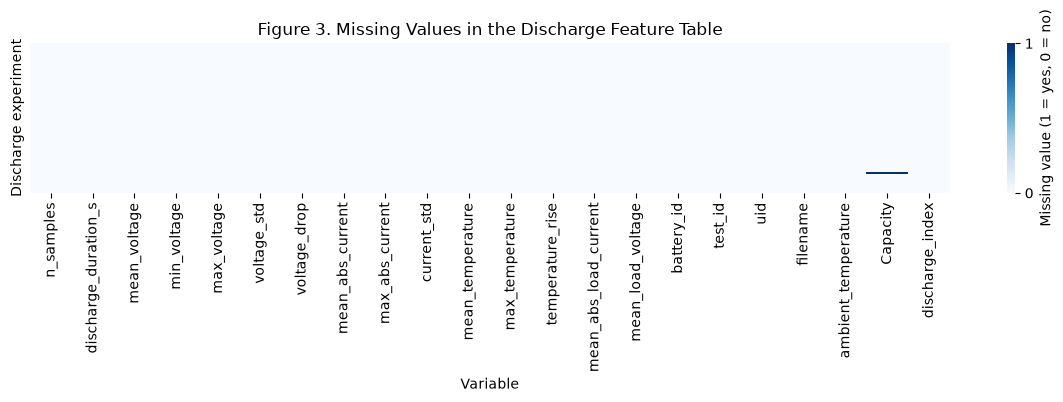

In [16]:
# Figure 3
plt.figure(figsize=(12, 4))
sns.heatmap(
    df.isna(),
    cmap="Blues",
    vmin=0,
    vmax=1,
    yticklabels=False,
    cbar_kws={"label": "Missing value (1 = yes, 0 = no)", "ticks": [0, 1]}
)

plt.title("Figure 3. Missing Values in the Discharge Feature Table")
plt.xlabel("Variable")
plt.ylabel("Discharge experiment")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_03_missing_values_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

The dataset is largely complete, with missing values appearing only in Capacity for 25 discharge experiments (about 0.9% of the data). The small dark region in the heatmap confirms that missingness is sparse rather than widespread across the predictors.

In [17]:
# Duplicate analytical rows
duplicate_count = df.duplicated(
    subset=["battery_id", "test_id", "filename"]
).sum()

print("Duplicate analytical rows:", duplicate_count)

# Basic validity checks
quality_checks = pd.Series({
    "Capacity <= 0": (df["Capacity"] <= 0).sum(),
    "Capacity missing": df["Capacity"].isna().sum(),
    "Duration <= 0": (df["discharge_duration_s"] <= 0).sum(),
    "Too few samples (<5)": (df["n_samples"] < 5).sum()
})
display(quality_checks.to_frame("count"))

Duplicate analytical rows: 0


,count
Capacity <= 0,19
Capacity missing,25
Duration <= 0,0
Too few samples (<5),2


In [18]:
# Validity mask defined once and reused for eda_df in Task 3
valid_mask = (
    df["Capacity"].notna() &
    (df["Capacity"] > 0) &
    (df["n_samples"] >= 5)
)
quality_df = df[valid_mask].copy()

outlier_cols = [
    "Capacity",
    "mean_voltage",
    "mean_abs_current",
    "mean_temperature",
    "max_temperature",
    "voltage_drop"
]

outlier_rows = []

for col in outlier_cols:
    s = quality_df[col].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((s < lower) | (s > upper)).sum()

    outlier_rows.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": outlier_count / len(s) * 100
    })

outlier_summary = pd.DataFrame(outlier_rows)

display(outlier_summary)

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
0,Capacity,0.379,2.451,195,7.091
1,mean_voltage,3.183,3.675,355,12.909
2,mean_abs_current,-0.256,3.265,206,7.491
3,mean_temperature,-22.218,68.293,0,0.000
4,max_temperature,-20.442,80.887,0,0.000
5,voltage_drop,-0.571,2.268,7,0.255


The IQR method is used to flag unusually high or low observations in important variables. These values are documented rather than deleted immediately because unusual battery behaviour may be meaningful for degradation analysis.

### 2.1 Regime-aware outlier check

Pooled IQR fences are computed over a multimodal mix of temperature regimes, so they can flag whole regimes rather than unusual cycles. The same rule is repeated within each ambient-temperature group for comparison.

In [19]:
regime_rows = []
for col in outlier_cols:
    flagged = 0
    for _, g in quality_df.groupby("ambient_temperature"):
        s = g[col].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        flagged += ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    regime_rows.append({"feature": col, "within_group_count": flagged,
                        "within_group_percent": flagged / len(quality_df) * 100})

regime_outliers = outlier_summary[["feature", "outlier_count", "outlier_percent"]].merge(
    pd.DataFrame(regime_rows), on="feature"
).rename(columns={"outlier_count": "pooled_count", "outlier_percent": "pooled_percent"})

display(regime_outliers)

,feature,pooled_count,pooled_percent,within_group_count,within_group_percent
0,Capacity,195,7.091,56,2.036
1,mean_voltage,355,12.909,383,13.927
2,mean_abs_current,206,7.491,218,7.927
3,mean_temperature,0,0.000,67,2.436
4,max_temperature,0,0.000,59,2.145
5,voltage_drop,7,0.255,282,10.255


### 2.2 Exclusion audit and near-zero Capacity

Removed rows are counted by battery to check whether exclusions cluster. Retained rows with very low Capacity are located by battery and ambient temperature before being interpreted as degradation.

In [20]:
excluded = df.loc[~valid_mask].assign(
    reason=np.select(
        [df.loc[~valid_mask, "Capacity"].isna(),
         df.loc[~valid_mask, "Capacity"] <= 0],
        ["Capacity missing", "Capacity <= 0"],
        default="n_samples < 5"
    )
)
print("Rows removed:", len(excluded))
display(pd.crosstab(excluded["battery_id"], excluded["reason"], margins=True))

Rows removed: 44


reason,Capacity <= 0,Capacity missing,All
battery_id,,,
B0042,1,0,1
B0043,1,0,1
B0044,1,0,1
B0045,2,0,2
B0046,3,0,3
B0047,3,0,3
B0048,3,0,3
B0049,1,0,1
B0050,1,4,5


In [21]:
NEAR_ZERO_AH = 0.3

near_zero = quality_df[quality_df["Capacity"] < NEAR_ZERO_AH]
print(f"Rows with Capacity < {NEAR_ZERO_AH} Ah:", len(near_zero))

display(
    near_zero.groupby(["battery_id", "ambient_temperature"])
             .agg(rows=("Capacity", "size"),
                  min_capacity=("Capacity", "min"),
                  median_capacity=("Capacity", "median"),
                  first_index=("discharge_index", "min"),
                  last_index=("discharge_index", "max"))
             .reset_index()
             .sort_values("rows", ascending=False)
)

RATED_AH = 2.0
print(f"Rows with Capacity above rated {RATED_AH} Ah:",
      int((quality_df["Capacity"] > RATED_AH).sum()))

Rows with Capacity < 0.3 Ah: 193


,battery_id,ambient_temperature,rows,min_capacity,median_capacity,first_index,last_index
3,B0042,4,46,0.062,0.085,42,87
4,B0043,4,46,0.057,0.067,42,87
5,B0044,4,46,0.055,0.061,42,87
2,B0041,4,42,0.044,0.047,1,42
0,B0033,24,6,0.068,0.235,1,144
6,B0050,4,5,0.033,0.096,5,21
1,B0039,24,2,0.119,0.141,1,3


Rows with Capacity above rated 2.0 Ah: 11


### 2.3 Target cross-check 

NASA reports `Capacity` for discharge to 2.7 V. Integrating |current| over time up to the first 2.7 V sample gives an independent estimate. Large disagreements point to traces or protocols that need review. This value is **not** used as a predictor.

In [22]:
_trapz = getattr(np, "trapezoid", None) or np.trapz
CUTOFF_V = 2.7

def coulomb_count_ah(file_path, cutoff=CUTOFF_V):
    x = pd.read_csv(file_path, usecols=["Voltage_measured", "Current_measured", "Time"])
    x = x.apply(pd.to_numeric, errors="coerce").dropna().sort_values("Time")
    if len(x) < 2:
        return np.nan
    below = np.flatnonzero(x["Voltage_measured"].to_numpy() <= cutoff)
    end = below[0] + 1 if len(below) else len(x)
    seg = x.iloc[:end]
    return _trapz(seg["Current_measured"].abs(), seg["Time"]) / 3600

quality_df["capacity_cc_2v7"] = [
    coulomb_count_ah(DATA_DIR / f) for f in quality_df["filename"]
]
quality_df["cc_abs_diff"] = (quality_df["capacity_cc_2v7"] - quality_df["Capacity"]).abs()

print("Pearson r (coulomb count vs Capacity):",
      round(quality_df[["capacity_cc_2v7", "Capacity"]].corr().iloc[0, 1], 3))
print("Median absolute difference (Ah):", round(quality_df["cc_abs_diff"].median(), 3))

display(
    quality_df.nlargest(10, "cc_abs_diff")[
        ["battery_id", "test_id", "ambient_temperature", "Capacity",
         "capacity_cc_2v7", "cc_abs_diff", "min_voltage", "n_samples"]
    ]
)

Pearson r (coulomb count vs Capacity): 1.0
Median absolute difference (Ah): 0.0


,battery_id,test_id,ambient_temperature,Capacity,capacity_cc_2v7,cc_abs_diff,min_voltage,n_samples
660,B0025,69,24,1.796,1.797,0.001,1.832,545
658,B0025,65,24,1.807,1.808,0.001,1.889,555
653,B0025,50,24,1.813,1.813,0.001,1.736,559
661,B0025,71,24,1.791,1.792,0.001,1.897,541
663,B0025,77,24,1.768,1.769,0.001,1.968,531
648,B0025,36,24,1.830,1.831,0.001,1.934,589
662,B0025,73,24,1.785,1.786,0.001,1.993,539
659,B0025,67,24,1.790,1.791,0.001,1.756,549
744,B0028,69,24,1.741,1.742,0.001,2.674,545
652,B0025,46,24,1.793,1.793,0.001,1.949,565


*Figure 4. Boxplots of Numerical Battery Features*

The boxplots show the spread and potential outliers in numerical measurements, experiment diagnostics and `Capacity` after validity filtering (n = 2,750), the same population as the IQR table; identifier columns are excluded. Each panel uses its own scale, and points beyond the whiskers are retained because they may reflect real operating conditions.

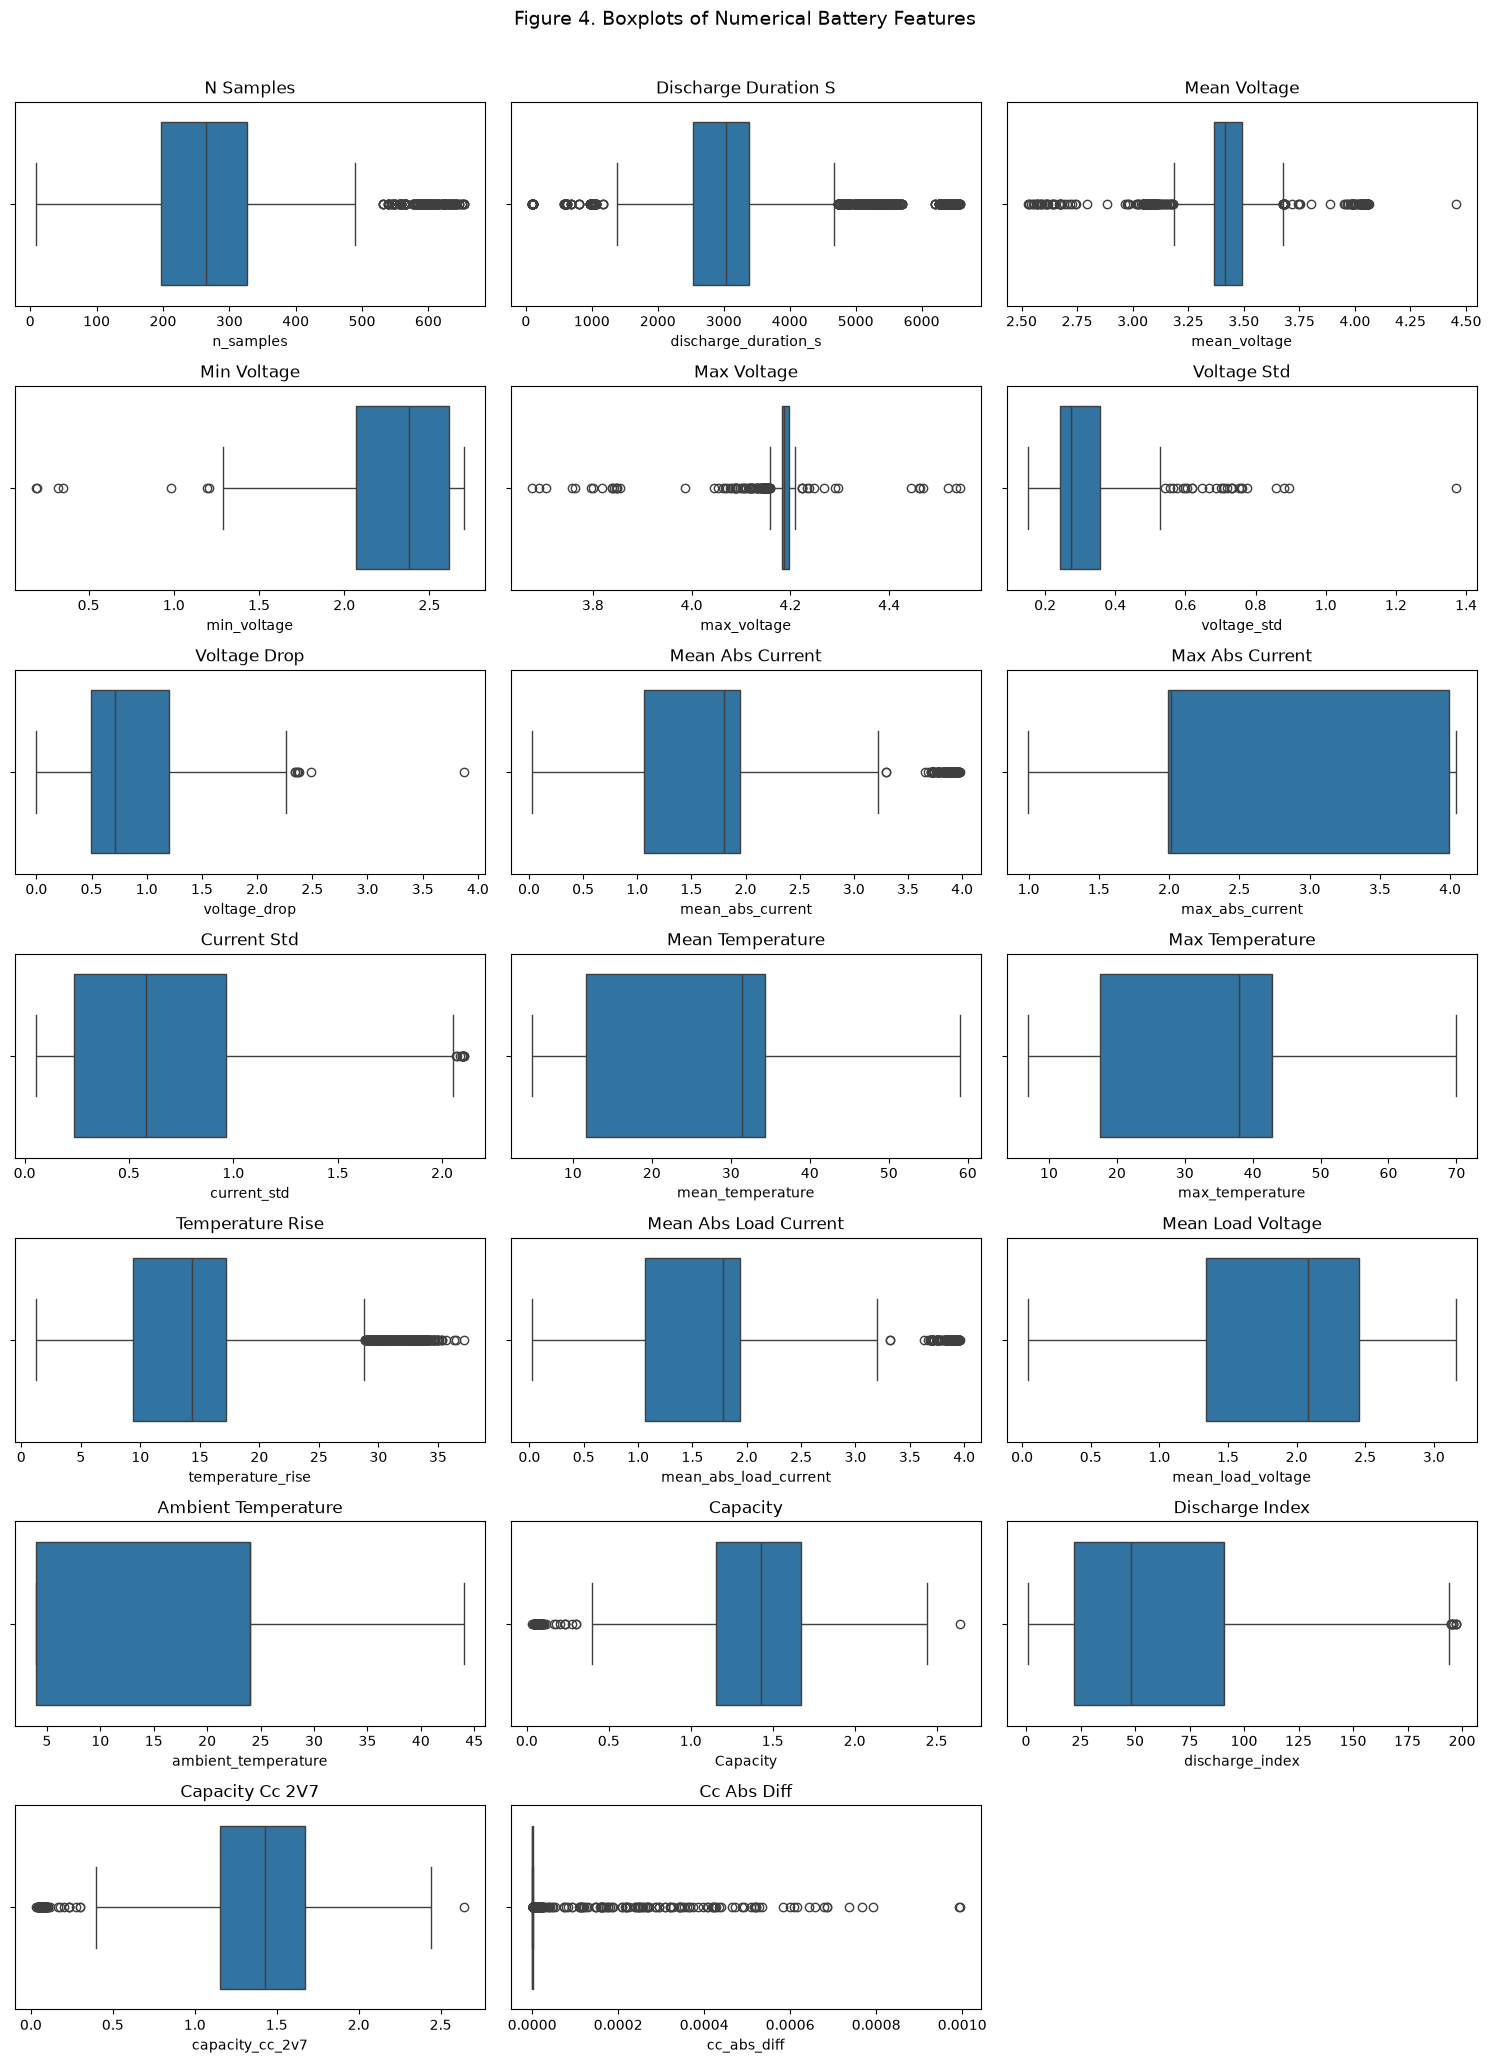

In [23]:
# Figure 4
numeric_cols = (
    quality_df.select_dtypes(include="number")
      .columns.drop(["test_id", "uid"])
      .tolist()
)

n_rows = (len(numeric_cols) + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 3 * n_rows))

for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(x=quality_df[col], ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col)

for ax in axes.ravel()[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle("Figure 4. Boxplots of Numerical Battery Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    FIG_DIR / "figure_04_numerical_boxplots.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

*Figure 5. IQR Outliers in Selected Variables*

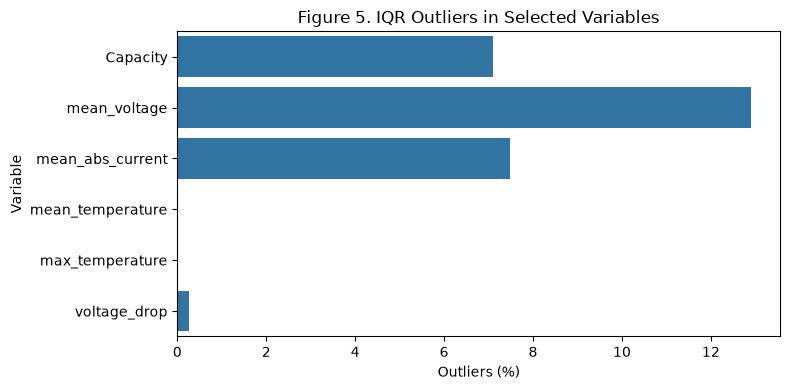

In [24]:
# Figure 5
plt.figure(figsize=(8, 4))

sns.barplot(
    data=outlier_summary,
    x="outlier_percent",
    y="feature"
)

plt.title("Figure 5. IQR Outliers in Selected Variables")
plt.xlabel("Outliers (%)")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_05_iqr_outliers.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Task 3: Target Variable Preparation

### 3.1. Numerical Target Variables

`Capacity` is a continuous measurement in ampere-hours, so the main prediction problem is **regression**. Rows with missing or non-positive Capacity and extremely short experiments are removed, while valid positive observations are retained.

In [25]:
eda_df = df[valid_mask].copy()

eda_df["battery_id"] = eda_df["battery_id"].astype("category")

print("Original shape:", df.shape)
print("EDA shape:", eda_df.shape)

display(eda_df["Capacity"].describe().to_frame().T)

Original shape: (2794, 22)
EDA shape: (2750, 22)


,count,mean,std,min,25%,50%,75%,max
Capacity,2750.000,1.336,0.461,0.033,1.156,1.431,1.674,2.640


In [26]:
lineage = pd.DataFrame([
    ("metadata.csv", *meta.shape, "34 batteries; all experiment types"),
    ("Discharge feature table", *df.shape, "one row per discharge experiment"),
    ("After validity mask", *eda_df.shape, f"{len(df) - len(eda_df)} rows removed"),
], columns=["stage", "rows", "columns", "note"])
display(lineage)

,stage,rows,columns,note
0,metadata.csv,7565,10,34 batteries; all experiment types
1,Discharge feature table,2794,22,one row per discharge experiment
2,After validity mask,2750,22,44 rows removed


Very low but positive Capacity measurements are retained because positivity alone does not establish that they are erroneous. Their validity should be interpreted together with battery identity, discharge duration and experimental conditions rather than removed using an arbitrary Capacity threshold.

*Figure 6. Distribution of Numerical Target: Capacity*

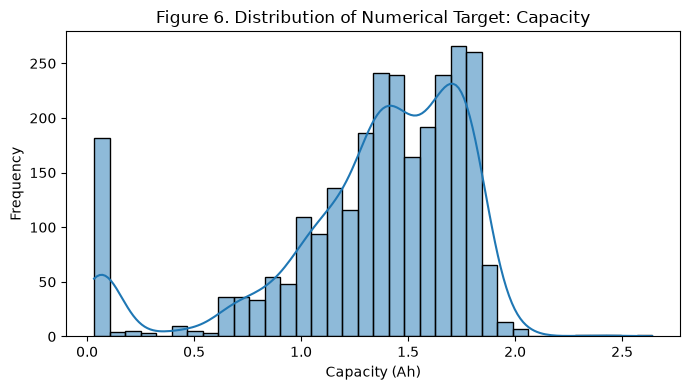

In [27]:
# Figure 6
plt.figure(figsize=(7, 4))

sns.histplot(
    data=eda_df,
    x="Capacity",
    kde=True
)

plt.title("Figure 6. Distribution of Numerical Target: Capacity")
plt.xlabel("Capacity (Ah)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_06_capacity_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### 3.2. Categorical Target Variables

For categorical target analysis, Capacity is divided into `Low`, `Medium`, and `High` groups using tertiles. These approximately balanced classes are used only for descriptive analysis; the original continuous Capacity remains the main modelling target.

In [28]:
eda_df["capacity_class"] = pd.qcut(
    eda_df["Capacity"],
    q=3,
    labels=["Low", "Medium", "High"]
)

display(
    eda_df["capacity_class"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

,count
capacity_class,
Low,917
Medium,916
High,917


The classes are nearly evenly distributed, with High and Low equal and Medium differing by only one observation.

## Task 4: Univariate Analysis

The distributions of key predictors are examined individually to identify their range, spread and possible skewness. Voltage, current, temperature and cycle-related features represent different aspects of battery operation and degradation.

The full set of 15 selected predictors and their summary statistics are shown below. `n_samples` and `discharge_duration_s` remain experiment diagnostics outside this predictor set; identifiers and target-derived `capacity_class` are also excluded.

In [29]:
predictors = [
    "discharge_index",
    "ambient_temperature",
    "mean_voltage",
    "min_voltage",
    "max_voltage",
    "voltage_std",
    "voltage_drop",
    "mean_abs_current",
    "max_abs_current",
    "current_std",
    "mean_temperature",
    "max_temperature",
    "temperature_rise",
    "mean_abs_load_current",
    "mean_load_voltage"
]

print("Summary statistics for all predictors:")
display(eda_df[predictors].describe())

Summary statistics for all predictors:


,discharge_index,ambient_temperature,mean_voltage,min_voltage,max_voltage,voltage_std,voltage_drop,mean_abs_current,max_abs_current,current_std,mean_temperature,max_temperature,temperature_rise,mean_abs_load_current,mean_load_voltage
count,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000,2750.000
mean,60.928,18.582,3.430,2.314,4.186,0.303,0.899,1.732,2.469,0.770,27.071,34.614,15.086,1.728,1.836
std,48.382,12.294,0.198,0.297,0.037,0.083,0.566,0.782,1.104,0.634,13.848,16.276,8.200,0.780,0.855
min,1.000,4.000,2.530,0.193,3.677,0.152,-0.001,0.029,0.997,0.056,4.858,6.936,1.255,0.026,0.044
25%,22.000,4.000,3.367,2.072,4.182,0.243,0.494,1.065,1.994,0.236,11.723,17.556,9.410,1.062,1.340
50%,48.000,24.000,3.416,2.379,4.187,0.275,0.711,1.796,2.014,0.582,31.379,37.913,14.336,1.785,2.080
75%,91.000,24.000,3.490,2.616,4.197,0.357,1.204,1.945,3.993,0.966,34.351,42.889,17.181,1.939,2.457
max,197.000,44.000,4.453,2.700,4.542,1.370,3.870,3.977,4.039,2.103,58.955,69.870,37.154,3.958,3.158


*Figure 7. Distributions of Key Predictor Variables*

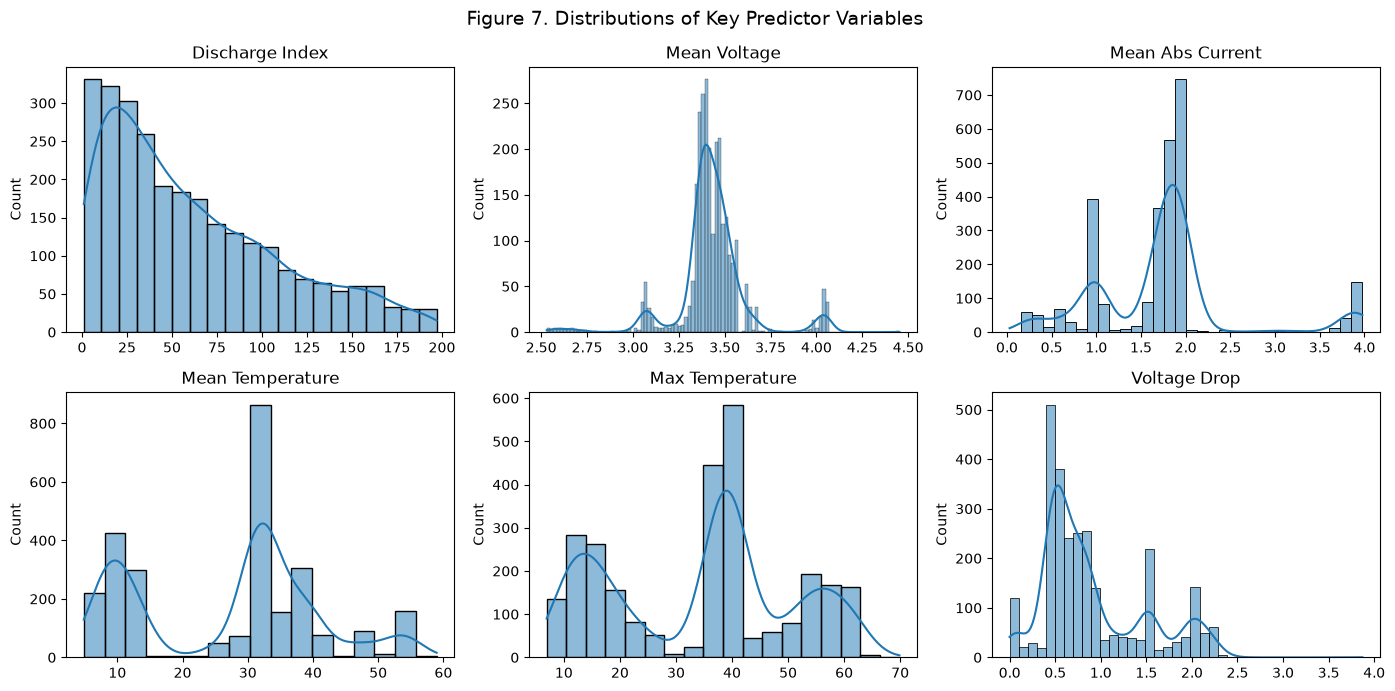

In [30]:
univariate_cols = [
    "discharge_index",
    "mean_voltage",
    "mean_abs_current",
    "mean_temperature",
    "max_temperature",
    "voltage_drop"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.ravel(), univariate_cols):
    sns.histplot(eda_df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")

fig.suptitle(
    "Figure 7. Distributions of Key Predictor Variables",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_07_predictor_distributions.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Several predictors show multimodal rather than single continuous distributions, especially current and temperature measurements. This indicates distinct operating regimes, so differences between observations may reflect both battery ageing and experimental conditions.

The variables also operate on different numerical scales, which should be considered before using scale-sensitive models.

## Task 5: Multivariate Analysis

Correlation analysis is used to examine relationships between `Capacity` and the numerical predictors. Identifier variables are excluded because they do not represent physical battery measurements.

*Figure 8. Correlation Matrix of Battery Features*

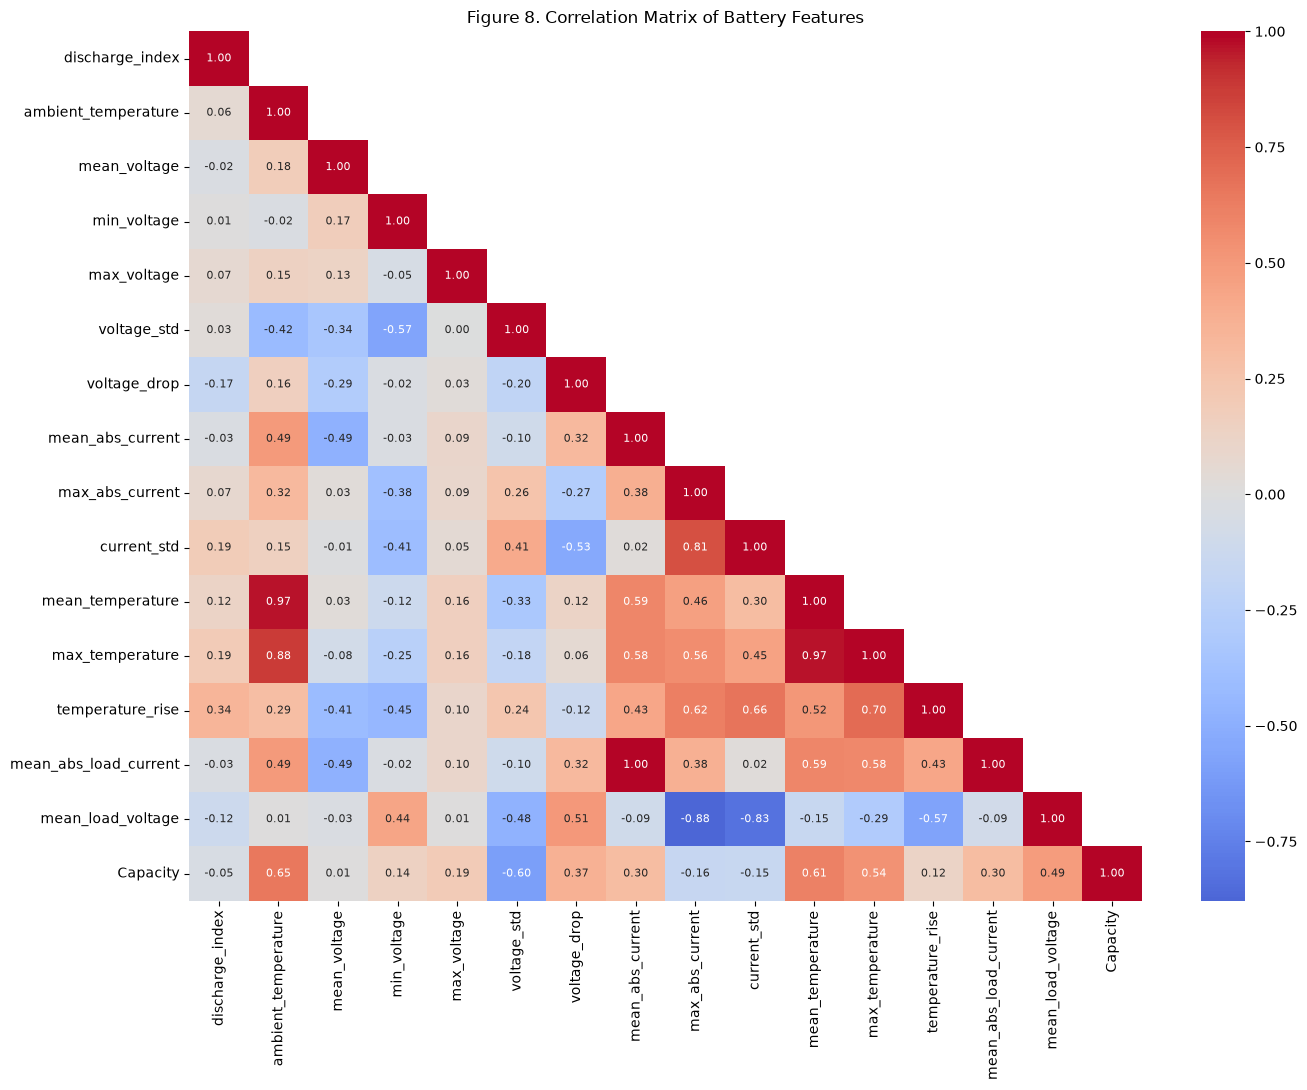

In [31]:
corr = eda_df[predictors + ["Capacity"]].corr(numeric_only=True)

plt.figure(figsize=(14, 11)) 

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # hide upper triangle

sns.heatmap(
    corr,
    mask=mask,
    annot=True,              
    fmt=".2f",              
    annot_kws={"size": 8},   
    cmap="coolwarm",
    center=0
)

plt.title("Figure 8. Correlation Matrix of Battery Features")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_08_correlation_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Top 3 Features Correlated with `Capacity`

The three strongest Pearson correlations are ranked by absolute magnitude, while their signed coefficients show the direction of association. Correlation is descriptive and does not establish that a feature independently causes Capacity change.

In [32]:
capacity_corr = (
    corr["Capacity"]
    .drop("Capacity")
    .sort_values(key=abs, ascending=False)
)

print("Top 3 features correlated with Capacity (Pearson r):")
display(capacity_corr.head(3).to_frame("correlation"))

# Strong predictor-predictor correlations indicate redundant information
predictor_corr = eda_df[predictors].corr(numeric_only=True).abs()
upper = predictor_corr.where(
    np.triu(np.ones(predictor_corr.shape), k=1).astype(bool)
)

strong_pairs = (
    upper.stack()
         .sort_values(ascending=False)
         .rename("abs_correlation")
         .reset_index()
         .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

display(strong_pairs[strong_pairs["abs_correlation"] >= 0.90].head(10))

Top 3 features correlated with Capacity (Pearson r):


,correlation
ambient_temperature,0.651
mean_temperature,0.608
voltage_std,-0.598


,feature_1,feature_2,abs_correlation
0,mean_abs_current,mean_abs_load_current,1.000
1,mean_temperature,max_temperature,0.970
2,ambient_temperature,mean_temperature,0.965


### 5.1 Battery structure and correlation by level

Rows are repeated measurements from 34 batteries. Each association is therefore checked pooled, between batteries (per-battery medians) and within batteries, using both Pearson and Spearman coefficients.

In [33]:
temps_per_battery = eda_df.groupby("battery_id", observed=True)["ambient_temperature"].nunique()
print("Batteries with a single ambient temperature:",
      int((temps_per_battery == 1).sum()), "of", len(temps_per_battery))

Batteries with a single ambient temperature: 28 of 34


In [34]:
level_vars = capacity_corr.head(3).index.tolist() + ["discharge_index"]
battery_medians = eda_df.groupby("battery_id", observed=True)[level_vars + ["Capacity"]].median()

def within_battery(col, method):
    vals = []
    for _, g in eda_df.groupby("battery_id", observed=True):
        if g[col].nunique() > 1 and g["Capacity"].nunique() > 1:
            vals.append(g[col].corr(g["Capacity"], method=method))
    return np.median(vals) if vals else np.nan

level_table = pd.DataFrame({
    "pooled_pearson": [eda_df[c].corr(eda_df["Capacity"]) for c in level_vars],
    "pooled_spearman": [eda_df[c].corr(eda_df["Capacity"], method="spearman") for c in level_vars],
    "battery_level_spearman": [battery_medians[c].corr(battery_medians["Capacity"], method="spearman")
                               if c != "discharge_index" else np.nan for c in level_vars],
    "median_within_pearson": [within_battery(c, "pearson") for c in level_vars],
    "median_within_spearman": [within_battery(c, "spearman") for c in level_vars],
}, index=level_vars).round(3)

display(level_table)

,pooled_pearson,pooled_spearman,battery_level_spearman,median_within_pearson,median_within_spearman
ambient_temperature,0.651,0.727,0.828,0.778,0.773
mean_temperature,0.608,0.542,0.728,0.091,-0.050
voltage_std,-0.598,-0.671,-0.662,-0.487,-0.527
discharge_index,-0.048,-0.216,NaN,-0.658,-0.818


`NaN` within batteries means the variable does not vary inside a battery, so a within-battery correlation is undefined. `battery_level_spearman` for `discharge_index` is omitted because a median cycle index is not meaningful.

In [35]:
# VIF via 1 / (1 - R^2), regressing each predictor on the others
X = eda_df[predictors].astype(float)
constant = X.columns[X.std() == 0].tolist()
if constant:
    print("Constant columns skipped:", constant)
X = X.drop(columns=constant)
X = (X - X.mean()) / X.std()

vif = {}
for col in X.columns:
    y = X[col].to_numpy()
    others = X.drop(columns=col).to_numpy()
    A = np.column_stack([np.ones(len(others)), others])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    r2 = 1 - ((y - A @ coef) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    vif[col] = np.inf if r2 >= 1 else 1 / (1 - r2)

vif = pd.Series(vif, name="VIF").sort_values(ascending=False).round(1)
print("Predictors with VIF > 10:", int((vif > 10).sum()), "of", len(vif))
display(vif.to_frame())

Predictors with VIF > 10: 9 of 15


,VIF
mean_abs_current,8516.400
mean_abs_load_current,8430.200
max_temperature,776.000
mean_temperature,594.900
ambient_temperature,229.300
temperature_rise,87.500
max_abs_current,25.600
mean_load_voltage,16.300
current_std,12.200
mean_voltage,6.000


Temperature-related variables rank among the strongest associations with Capacity, but several are also highly correlated with one another. Likewise, measured current and load current describe closely related electrical behaviour. Future modelling should avoid treating highly redundant measurements as independent information.

*Figure 9. Pairplot of the Top 3 Correlated Features and Capacity*

The pairplot compares `Capacity` with the three predictors having the strongest absolute correlations, with histograms on the diagonal. The temperature variables are related to one another, so their associations with Capacity should not be treated as independent effects.

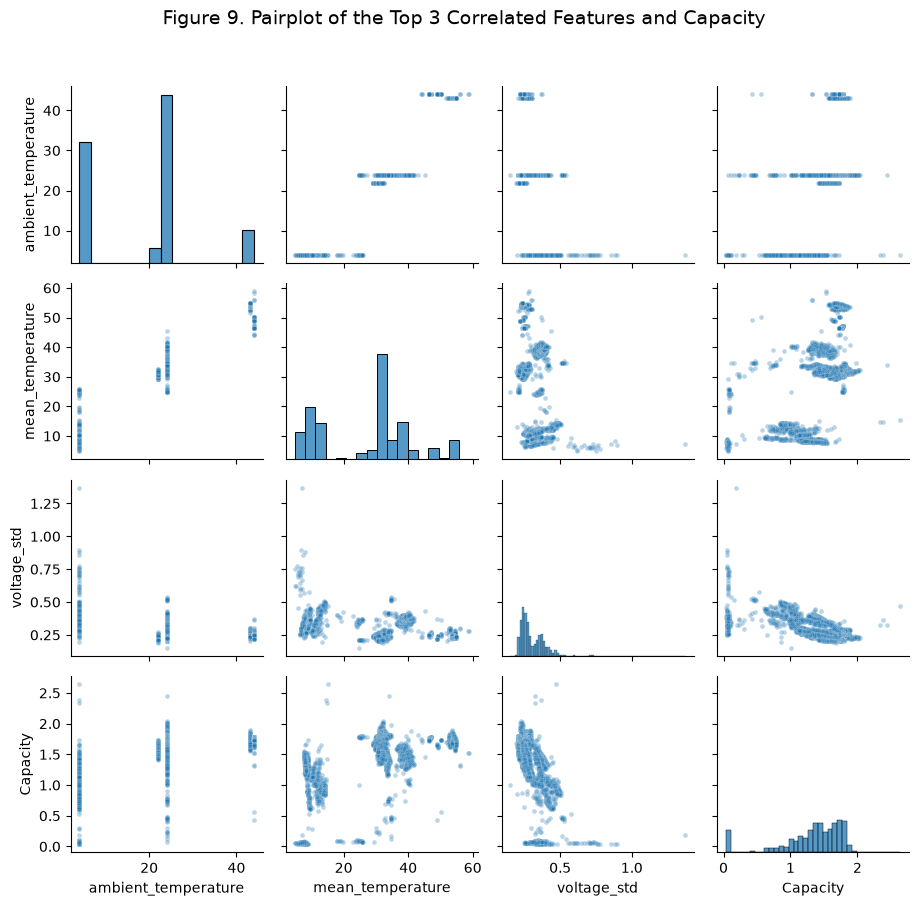

In [36]:
# Figure 9
pairplot_cols = capacity_corr.head(3).index.tolist() + ["Capacity"]

g = sns.pairplot(
    data=eda_df[pairplot_cols],
    diag_kind="hist",
    plot_kws={"alpha": 0.3, "s": 12},
    height=2.3
)

g.fig.suptitle(
    "Figure 9. Pairplot of the Top 3 Correlated Features and Capacity",
    fontsize=14
)
g.fig.tight_layout(rect=[0, 0, 1, 0.95])

g.savefig(
    FIG_DIR / "figure_09_capacity_pairplot.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

*Figure 10. Capacity vs Discharge Cycle Index*

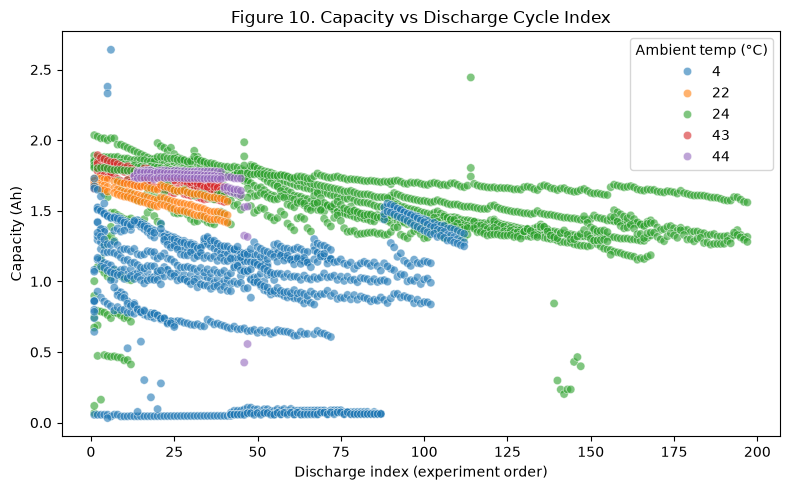

In [37]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=eda_df.assign(ambient_temp_C=eda_df["ambient_temperature"].astype(str)),
    x="discharge_index",
    y="Capacity",
    hue="ambient_temp_C",
    hue_order=sorted(eda_df["ambient_temperature"].unique().astype(str), key=int),
    palette="tab10",
    alpha=0.6
)
plt.legend(title="Ambient temp (°C)")

plt.title("Figure 10. Capacity vs Discharge Cycle Index")
plt.xlabel("Discharge index (experiment order)")
plt.ylabel("Capacity (Ah)")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_10_capacity_vs_cycle.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

The pooled relationship between discharge order and Capacity is weak because observations from different batteries and operating conditions overlap. Distinct groups are visible across temperature and battery conditions, so ageing is more meaningfully assessed within individual batteries than across all discharge records pooled together.

In [38]:
battery_discharge_corr = pd.Series({
    battery: group["discharge_index"].corr(
        group["Capacity"],
        method="spearman"
    )
    for battery, group in eda_df.groupby("battery_id", observed=True)
}, name="discharge_index_capacity_correlation")

display(battery_discharge_corr.describe().to_frame())

,discharge_index_capacity_correlation
count,34.000
mean,-0.651
std,0.432
min,-0.993
25%,-0.941
50%,-0.818
75%,-0.571
max,0.690


Battery: B0041 | Spearman: 0.69


,count,mean,std,min,25%,50%,75%,max
discharge_index,67.000,34.000,19.485,1.000,17.500,34.000,50.500,67.000
Capacity,67.000,0.386,0.445,0.044,0.047,0.048,0.890,1.216
ambient_temperature,67.000,4.000,0.000,4.000,4.000,4.000,4.000,4.000
mean_abs_current,67.000,0.580,0.458,0.226,0.247,0.399,0.693,1.962
min_voltage,67.000,1.922,0.063,1.751,1.874,1.948,1.973,1.999


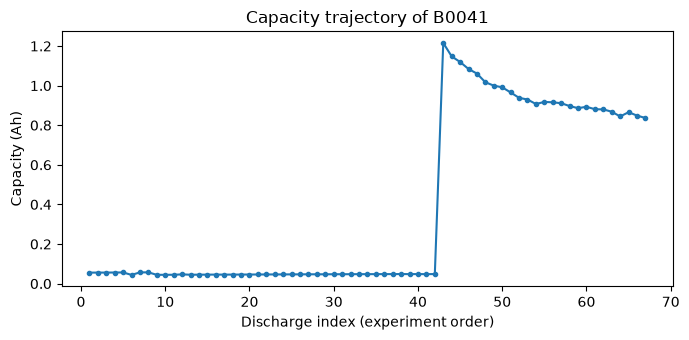

In [39]:
# Battery with the least negative (most positive) within-battery trend
odd_battery = battery_discharge_corr.idxmax()
print("Battery:", odd_battery, "| Spearman:", round(battery_discharge_corr.max(), 3))

odd = eda_df[eda_df["battery_id"] == odd_battery]
display(odd[["discharge_index", "Capacity", "ambient_temperature", "mean_abs_current", "min_voltage"]].describe().T)

plt.figure(figsize=(7, 3.5))
plt.plot(odd["discharge_index"], odd["Capacity"], marker="o", ms=3)
plt.title(f"Capacity trajectory of {odd_battery}")
plt.xlabel("Discharge index (experiment order)")
plt.ylabel("Capacity (Ah)")
plt.tight_layout()
plt.show()

Battery-specific correlations separate within-battery ageing behaviour from differences between batteries. This is important because the thousands of discharge rows are repeated measurements from only a few dozen physical batteries, not thousands of independent battery samples.

## Task 6: Engineering Interpretation

Battery degradation is a repeated-cycle process. Figure 11 compares capacity trajectories across batteries and ambient temperatures.

*Figure 11. Capacity Trajectories per Battery by Ambient Temperature*

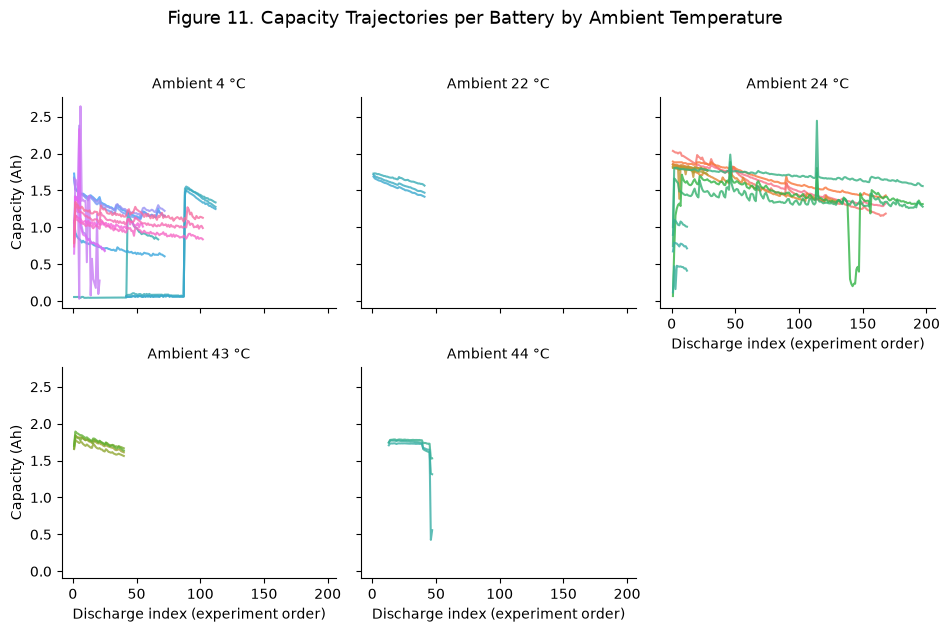

In [40]:
# Figure 11: one panel per ambient temperature so trajectories are readable
g = sns.relplot(
    data=eda_df,
    x="discharge_index",
    y="Capacity",
    hue="battery_id",
    col="ambient_temperature",
    col_wrap=3,
    kind="line",
    estimator=None,
    alpha=0.8,
    height=3.2,
    legend=False,
    facet_kws={"sharex": True, "sharey": True}
)
g.set_titles("Ambient {col_name} °C")
g.set_axis_labels("Discharge index (experiment order)", "Capacity (Ah)")
g.fig.suptitle("Figure 11. Capacity Trajectories per Battery by Ambient Temperature", fontsize=13)
g.fig.tight_layout(rect=[0, 0, 1, 0.95])

g.savefig(
    FIG_DIR / "figure_11_capacity_degradation.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


Most batteries show declining Capacity, consistent with ageing, but abrupt drops and spikes also occur — a short-term decrease should not be read as permanent degradation on its own (discussed in the report, §6).

*Figure 12. Capacity Distribution by Ambient Temperature*

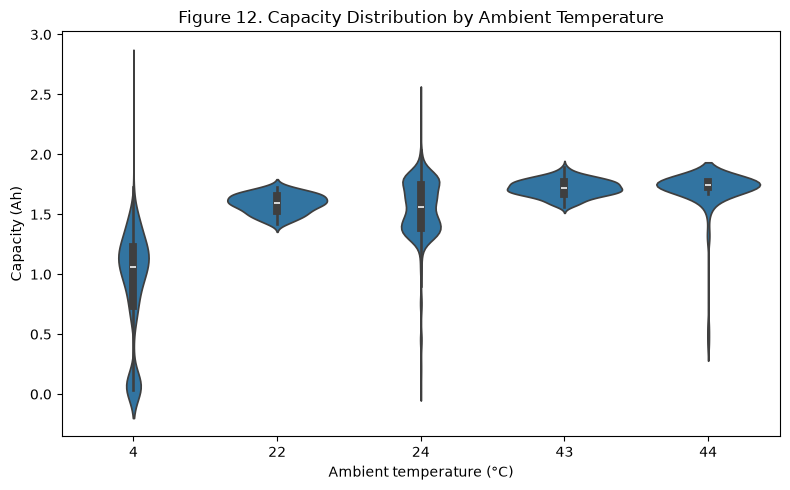

In [41]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=eda_df,
    x="ambient_temperature",
    y="Capacity"
)

plt.title("Figure 12. Capacity Distribution by Ambient Temperature")
plt.xlabel("Ambient temperature (°C)")
plt.ylabel("Capacity (Ah)")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_12_capacity_by_temperature.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Capacity is lower at low ambient temperature, consistent with slower reaction kinetics, but temperature groups also mix different batteries, so this is an association, not a proven cause (report §6).

### Engineering Interpretation Questions

**What do the correlations mean in engineering terms?**  
Capacity correlates positively with ambient and battery temperature (r ≈ 0.651, 0.608) and negatively with voltage variability (r ≈ −0.598), linking delivered charge to thermal conditions and discharge-voltage behaviour. Batteries and protocols are mixed together, so these are associations, not isolated causal effects.

**Are there any unexpected patterns from an engineering perspective?**  
The pooled discharge-index vs Capacity correlation is weak (r ≈ −0.048) despite clear within-battery ageing trends (A6) — pooling hides the signal. Abrupt capacity drops/spikes and some very low-capacity runs (A1) also depart from smooth degradation and remain unresolved.

**What physical/process relationships do the data reflect?**  
Capacity reflects current delivered over time; voltage and temperature trajectories reflect load and the battery's electrical and thermal response. Reduced capacity at low temperature fits slower reaction kinetics and greater polarization; longer-term decline fits ageing. The correlations alone cannot separate the two.

**Are there important missing features that could improve future modelling?**  
Rest duration, cumulative charge throughput and explicit load/cutoff settings would help separate usage history from operating conditions, but are absent from the current table. Impedance (`Re`, `Rct`) is already in the source data and unused here, and could be linked using only measurements available before the prediction time.

## Task 7: Challenges Encountered

The dataset contains thousands of separate experiment files rather than a single analysis-ready table, and it mixes charge, discharge and impedance tests. Discharge files therefore had to be selected and converted from variable-length sensor sequences into one row per experiment.

*Figure 13. Number of Sensor Samples per Discharge Experiment*

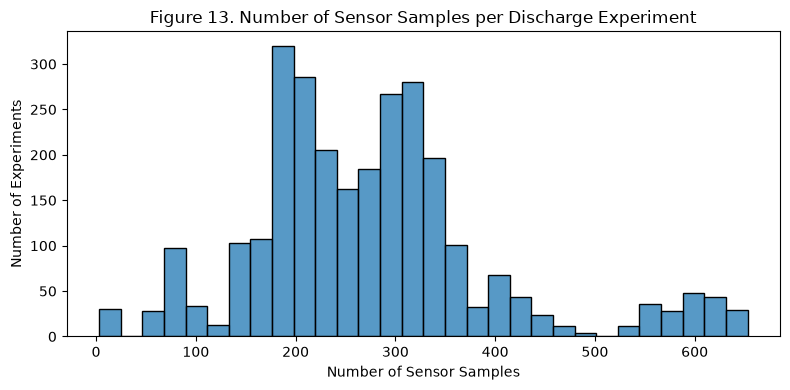

In [42]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="n_samples",
    bins=30
)

plt.title("Figure 13. Number of Sensor Samples per Discharge Experiment")
plt.xlabel("Number of Sensor Samples")
plt.ylabel("Number of Experiments")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_13_samples_per_experiment.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Discharge files contain different numbers of sensor samples, so the raw time series are not uniform in length. Feature aggregation makes them comparable for this EDA; a future sequence model would instead require an explicit strategy such as alignment, resampling, padding or masking.

## Task 8: Responsible AI Reflection Questions

Poor data quality reduces model reliability: missing, incorrect or noisy sensor readings can produce inaccurate engineered features, so a model learns measurement artefacts instead of genuine degradation patterns.

The main bias risk is experimental, not demographic: batteries and operating conditions are unevenly represented, so a model trained here may not generalise to other battery chemistries, manufacturers or environments.

*Figure 14. Number of Discharge Experiments per Battery*

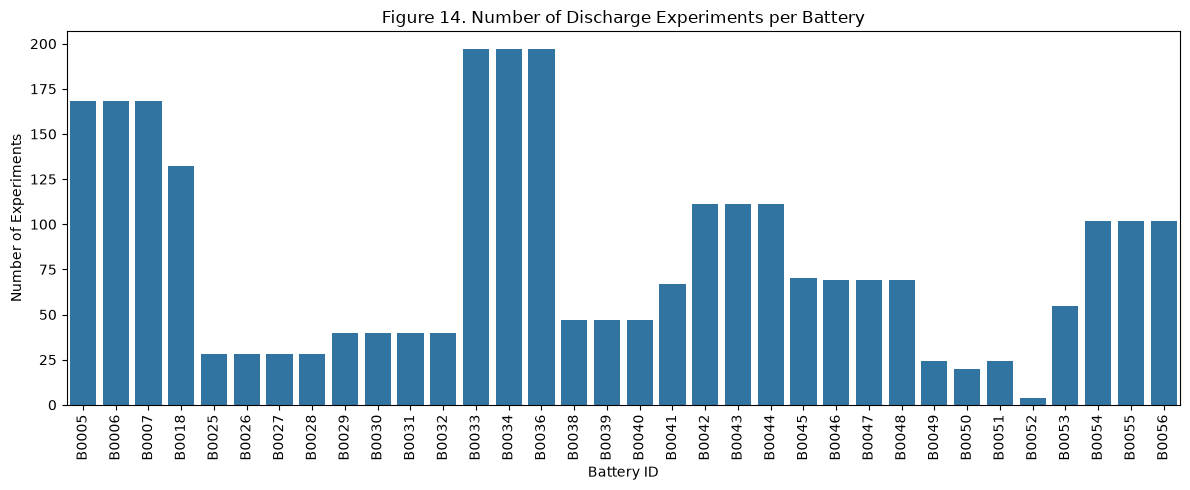

In [43]:
battery_counts = (
    eda_df["battery_id"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=battery_counts.index.astype(str),
    y=battery_counts.values
)

plt.title("Figure 14. Number of Discharge Experiments per Battery")
plt.xlabel("Battery ID")
plt.ylabel("Number of Experiments")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_14_experiments_per_battery.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Observations per battery vary, and the cleaned table holds repeated measurements from only 34 physical batteries — a random row-level split could place the same battery in both train and test and overestimate performance.

Future modelling should use battery-aware validation (`GroupKFold` or leave-battery-out) and should not assume results generalise to other cell chemistries, manufacturers or operating environments.

### Temporal Leakage Consideration

Several predictors summarise the complete discharge experiment, the same experiment `Capacity` is measured from. They suit this EDA, but a true early battery-health predictor should use only information available before the target discharge, or from a clearly defined early portion of the signal.

## Task 9: Summary Report

The EDA turns discharge time series into an analysis-ready table of electrical, thermal and operational features, with `Capacity` as the regression target. Capacity reflects both longitudinal battery ageing and experimental operating conditions, so pooled correlations need cautious interpretation (full discussion in the accompanying report).

Future modelling needs battery-aware validation, control of highly correlated predictors, consistent treatment of operating conditions, and prevention of temporal leakage.

Cleaned data and figures are saved under `output/`. The full discussion is in the accompanying report, submitted to Canvas as `Portfolio_Assessment_1_Le_Mai_Chi.pdf`.

In [44]:
eda_df.to_csv(CLEAN_DATA_PATH, index=False)

top3 = capacity_corr.head(3)

summary = pd.DataFrame({
    "Item": [
        "Metadata records",
        "Original discharge records",
        "Feature table shape",
        "Final EDA shape",
        "Number of batteries",
        "Candidate predictor variables",
        "Near-zero Capacity rows (< 0.3 Ah)",
        f"Top 1: {top3.index[0]} (r)",
        f"Top 2: {top3.index[1]} (r)",
        f"Top 3: {top3.index[2]} (r)",
        "Median within-battery Spearman (discharge_index vs Capacity)",
    ],
    "Value": [
        len(meta),
        len(df),
        str(df.shape),
        str(eda_df.shape),
        eda_df["battery_id"].nunique(),
        len(predictors),
        int((eda_df["Capacity"] < NEAR_ZERO_AH).sum()),
        round(top3.iloc[0], 3),
        round(top3.iloc[1], 3),
        round(top3.iloc[2], 3),
        round(battery_discharge_corr.median(), 3),
    ]
})

display(summary)
print("Clean dataset:", CLEAN_DATA_PATH)
print("Figures:", FIG_DIR)


,Item,Value
0,Metadata records,7565
1,Original discharge records,2794
2,Feature table shape,"(2794, 22)"
3,Final EDA shape,"(2750, 23)"
4,Number of batteries,34
5,Candidate predictor variables,15
6,Near-zero Capacity rows (< 0.3 Ah),193
7,Top 1: ambient_temperature (r),0.651
8,Top 2: mean_temperature (r),0.608
9,Top 3: voltage_std (r),-0.598


Clean dataset: ../output/nasa_battery_eda_clean.csv
Figures: ../output/figures
